In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
SMALL_SIZE = 18
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE) 
import sys, getopt
sys.path.append('../code/')
from mirrorLangevinMC import *
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import inv
from numpy.linalg import norm
from scipy.linalg import sqrtm
from scipy.linalg import null_space
from scipy.special import gamma, logit
from tqdm import tqdm


In [2]:
import sys, getopt
sys.path.append('../code/')
from mirrorLangevinMC import *
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import inv
from numpy.linalg import norm
from scipy.linalg import sqrtm
from scipy.linalg import null_space
from scipy.special import gamma, logit
from tqdm import tqdm

# parse and create directory
# step = float(sys.argv[1])
# import os
# path = os.getcwd() + "/" + str(step) 
# try:
#     os.mkdir(path)
# except:
#     print("Path already created, overwriting contents")




d = 2 
# Parameters
sm = 1
bi = 10000
x0 = -2 * np.ones(shape=(d,))
reps = 1

#################
n = 100
#Sigma = np.diag(np.arange(d)+1)

Sigma = 20 * np.eye(d) #np.diag(np.linspace(1, 101, d))

# Sigma = np.eye(d)
# Sigma[0,0] = 10
#beta = np.random.multivariate_normal(np.zeros(d, ), Sigma)
beta = np.ones((d,))
#beta[0] = 5

#beta = np.random.multivariate_normal(np.zeros(d, ), Sigma)
#np.array([[-1],[-0.1]])
#sqrtm(Sigma).dot(np.random.normal(size = (d, )))
# SigmaX = np.eye(d)
SigmaX = np.diag([10, .1])
X = np.random.multivariate_normal(np.zeros(d, ), SigmaX, n).T
Y = np.random.binomial(1, p = ilogit(beta.T.dot(X)))
#Sigma = np.linalg.pinv(np.cov(X))
def V(b):
    return (0.5 * b.T.dot(np.linalg.pinv(Sigma)).dot(b) - 
          np.sum(Y * b.T.dot(X)) + 
          np.sum(np.log(1 + np.exp(b.T.dot(X)))))
def grad_V(b):
    return (np.linalg.pinv(Sigma).dot(b) - 
          np.sum(np.outer(np.ones(d, ), Y) * X, axis = 1) + 
          np.sum(np.outer(np.ones(d, ), 
                          np.power(1 + np.exp(-b.T.dot(X)), -1)) * X, axis = 1))
def H_V(b):
    Z = X * (np.outer(np.ones(d, ), (np.exp(-b.T.dot(X)) * 
                                   np.power(1 + np.exp(-b.T.dot(X)), -2))))
    return (np.linalg.pinv(Sigma) + Z.dot(X.T))
####################






In [5]:
N = 100

mLs = np.zeros((d, reps))
mNs = np.zeros((d, reps))
mTs = np.zeros((d, reps))

CLs = np.zeros((d, d, reps))
CNs = np.zeros((d, d, reps))
CTs = np.zeros((d, d, reps))

YLs = np.zeros((d, sm * N, reps))
YNs = np.zeros((d, N, reps))
YTs = np.zeros((d, sm * N, reps))

tLs = np.zeros((sm * N, reps))
tNs = np.zeros((N, reps))
tTs = np.zeros((sm * N, reps))

mod1 = mirrorLangevinMC(V, grad_V, grad_V, H_V, inv_grad_V = True)

for r in tqdm(range(reps)):
    mLs[:, r], CLs[:, :, r], YLs[:, :, r], tLs[:, r] = mod1.ULA(x0, 0.1, sm * N, burn_in = bi, quiet = True)
    mNs[:, r], CNs[:, :, r], YNs[:, :, r], tNs[:, r] = mod1.NLA(x0, 0.1, N, burn_in = bi, quiet = True)
    mTs[:, r], CTs[:, :, r], YTs[:, :, r], tTs[:, r] = mod1.TULA(x0, 0.1, sm * N, gamma = 0.01, burn_in = bi, quiet = True)


#########
# save outputs
np.save('output' + '/mLs.npy', mLs)
np.save('output' + '/mNs.npy', mNs)
np.save('output' + '/mTs.npy', mTs)
np.save('output' + '/CLs.npy', CLs)
np.save('output' + '/CNs.npy', CNs)
np.save('output' + '/CTs.npy', CTs)
np.save('output' + '/YLs.npy', YLs)
np.save('output' + '/YNs.npy', YNs)
np.save('output' + '/YTs.npy', YTs)
np.save('output' + '/beta.npy', beta)
np.save('output' + '/tLs.npy', tLs)
np.save('output' + '/tNs.npy', tNs)
np.save('output' + '/tTs.npy', tTs)


np.save('output' + '/X.npy', X)
np.save('output' + '/Y.npy', Y)
np.save('output' + '/Sigma.npy', Sigma)

def ilogit(z):
    return np.exp(z) / (1 + np.exp(z))
    
YNs = np.load('output/YNs.npy')
d, N, reps = YNs.shape
YNs = YNs.reshape(d, N * reps)
YLs = np.load('output/YLs.npy')
YLs = YLs.reshape(d, N * reps)

YTs = np.load('output/YTs.npy')
YTs = YTs.reshape(d, N * reps)

beta = np.load('output/beta.npy')
X = np.load('output/X.npy')
Y = np.load('output/Y.npy')
Sigma = np.load('output/Sigma.npy')
#Sigma = 100 * np.eye(d)
d, n = X.shape


100%|██████████| 1/1 [00:43<00:00, 43.10s/it]


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:56: UserWarning: The following kwargs were not used by contour: 'color'


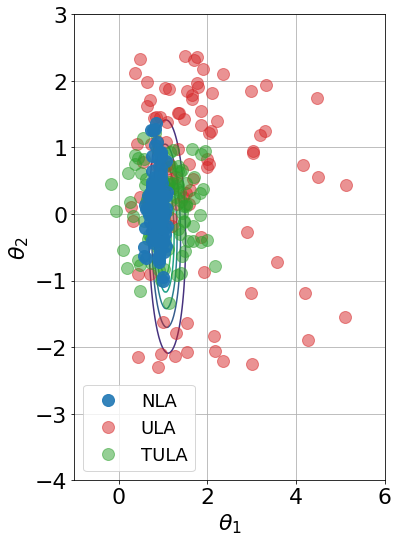

In [6]:

mLs = np.load('output' + '/mLs.npy' )
mNs = np.load('output' + '/mNs.npy' )
mTs = np.load('output' + '/mTs.npy')
CLs = np.load('output' + '/CLs.npy' )
CNs =np.load('output' + '/CNs.npy' )
CTs = np.load('output' + '/CTs.npy' )
YLs = np.load('output' + '/YLs.npy' )
YNs = np.load('output' + '/YNs.npy' )
YTs = np.load('output' + '/YTs.npy' )
beta = np.load('output' + '/beta.npy' )
tLs = np.load('output' + '/tLs.npy' )
tNs = np.load('output' + '/tNs.npy')
tTs = np.load('output' + '/tTs.npy' )


X = np.load('output' + '/X.npy')
Y = np.load('output' + '/Y.npy')
Sigma = np.load('output' + '/Sigma.npy')

def V(b):
    return (0.5 * b.T.dot(np.linalg.pinv(Sigma)).dot(b) - 
          np.sum(Y * b.T.dot(X)) + 
          np.sum(np.log(1 + np.exp(b.T.dot(X)))))

def grad_V(b):
    return (np.linalg.pinv(Sigma).dot(b) - 
          np.sum(np.outer(np.ones(d, ), Y) * X, axis = 1) + 
          np.sum(np.outer(np.ones(d, ), 
                          np.power(1 + np.exp(-b.T.dot(X)), -1)) * X, axis = 1))

def H_V(b):
    Z = X * (np.outer(np.ones(d, ), (np.exp(-b.T.dot(X)) * 
                                   np.power(1 + np.exp(-b.T.dot(X)), -2))))
    return (np.linalg.pinv(Sigma) + Z.dot(X.T))

def target_density(x):
    return np.exp(-V(x))

gridpts = 100
xs = np.linspace(-0, 3, num=gridpts)
ys = np.linspace(-4, 4, num=gridpts)
zs = np.zeros(shape=(gridpts, gridpts))
for i in range(gridpts):
    for j in range(gridpts):
        zs[j, i] = target_density(np.array([[xs[i]], [ys[j]]]))
XS, YS = np.meshgrid(xs, ys)

plt.figure(figsize = (6,8))
ax = plt.subplot(1,1,1)

plt.contour(XS, YS, zs, levels=6 , color = "tab:purple")
p3 = ax.plot(YNs[0,:], YNs[1,:], 'o', color = "tab:blue", alpha = 0.9, markersize = 12, label = 'NLA')


plt.grid()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim([-1, 6])
plt.ylim([-4, 3])





p1 = ax.plot(YLs[0,:], YLs[1,:], 'o', color = "tab:red", alpha = 0.5, markersize = 12, label = 'ULA')
# plt.plot(YLs[0,N-1,:], YLs[1,N-1,:], 'ro', alpha = 0.4)

# plt.contour(XS, YS, zs, levels=20 , cmap='RdGy')
# plt.grid()
# plt.xlabel(r'$\beta_1$')
# plt.ylabel(r'$\beta_2$')
#plt.ylim([-1, 3.5])
# plt.legend(['ULA'])
# plt.savefig('ULA_samples_LR.pdf')


# plt.figure(figsize = (8, 5))
p2 = ax.plot(YTs[0,:], YTs[1,:], 'o', color = "tab:green", alpha = 0.5, markersize = 12, label = 'TULA')


p3 = ax.plot(YNs[0,:], YNs[1,:], 'o', color = "tab:blue", alpha = 0.9, markersize = 12, label = 'NLA')

# plt.plot(YTs[0,N-1,:], YTs[1,N-1,:], 'go', alpha = 0.4)

# plt.contour(XS, YS, zs, levels=10 , cmap='RdGy')
# plt.grid()
# plt.xlabel(r'$\beta_1$')
# plt.ylabel(r'$\beta_2$')
#plt.ylim([-4, 4])
# plt.legend(['TULA'])
# plt.savefig('TULA_samples_LR.pdf')

# plt.xlim([-1, 2])
handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[2], handles[0], handles[1]], [labels[2], labels[0], labels[1]])
plt.tight_layout()
plt.savefig('samples_LR_largestep2.pdf')

100%|██████████| 1/1 [00:05<00:00,  5.01s/it]
/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:79: UserWarning: The following kwargs were not used by contour: 'color'


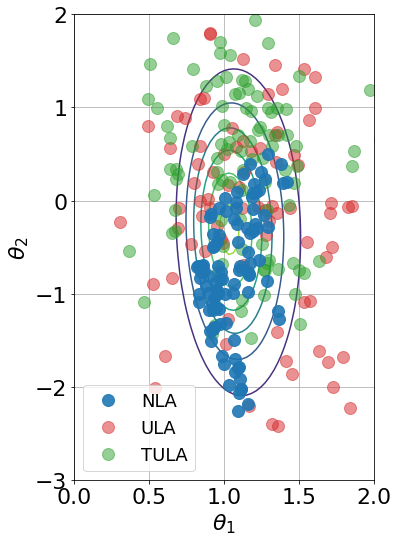

In [7]:
d = 2
reps = 1
sm = 1
x0 = np.ones(d,)

beta = np.load('output' + '/beta.npy' )
X = np.load('output' + '/X.npy')
Y = np.load('output' + '/Y.npy')
Sigma = np.load('output' + '/Sigma.npy')


N = 100

mLs = np.zeros((d, reps))
mNs = np.zeros((d, reps))
mTs = np.zeros((d, reps))

CLs = np.zeros((d, d, reps))
CNs = np.zeros((d, d, reps))
CTs = np.zeros((d, d, reps))

YLs = np.zeros((d, sm * N, reps))
YNs = np.zeros((d, N, reps))
YTs = np.zeros((d, sm * N, reps))

tLs = np.zeros((sm * N, reps))
tNs = np.zeros((N, reps))
tTs = np.zeros((sm * N, reps))

def V(b):
    return (0.5 * b.T.dot(np.linalg.pinv(Sigma)).dot(b) - 
          np.sum(Y * b.T.dot(X)) + 
          np.sum(np.log(1 + np.exp(b.T.dot(X)))))

def grad_V(b):
    return (np.linalg.pinv(Sigma).dot(b) - 
          np.sum(np.outer(np.ones(d, ), Y) * X, axis = 1) + 
          np.sum(np.outer(np.ones(d, ), 
                          np.power(1 + np.exp(-b.T.dot(X)), -1)) * X, axis = 1))

def H_V(b):
    Z = X * (np.outer(np.ones(d, ), (np.exp(-b.T.dot(X)) * 
                                   np.power(1 + np.exp(-b.T.dot(X)), -2))))
    return (np.linalg.pinv(Sigma) + Z.dot(X.T))

def target_density(x):
    return np.exp(-V(x))

mod1 = mirrorLangevinMC(V, grad_V, grad_V, H_V, inv_grad_V = True)

for r in tqdm(range(reps)):
    mLs[:, r], CLs[:, :, r], YLs[:, :, r], tLs[:, r] = mod1.ULA(x0, 0.05, sm * N, burn_in = 1000, quiet = True)
    mNs[:, r], CNs[:, :, r], YNs[:, :, r], tNs[:, r] = mod1.NLA(x0, 0.05, N, burn_in = 1000, quiet = True)
    mTs[:, r], CTs[:, :, r], YTs[:, :, r], tTs[:, r] = mod1.TULA(x0, 0.05, sm * N, gamma = 0.01, burn_in = 1000, quiet = True)







gridpts = 100
xs = np.linspace(-0, 3, num=gridpts)
ys = np.linspace(-4, 4, num=gridpts)
zs = np.zeros(shape=(gridpts, gridpts))
for i in range(gridpts):
    for j in range(gridpts):
        zs[j, i] = target_density(np.array([[xs[i]], [ys[j]]]))
XS, YS = np.meshgrid(xs, ys)
# plt.figure(figsize=(5,5))
# plt.title('True density') 

plt.figure(figsize = (6,8))
ax = plt.subplot(1,1,1)

#plt.figure(figsize = (6, 8))
# plt.plot(YNs[0,N-1,:], YNs[1,N-1,:], 'bo', alpha = 0.4)

plt.contour(XS, YS, zs, levels=6 , color = "tab:purple")
plt.grid()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.xlim([-0, 2])
plt.ylim([-3, 2])





p1 = ax.plot(YLs[0,:], YLs[1,:], 'o', color = "tab:red", alpha = 0.5, markersize = 12, label = 'ULA')
# plt.plot(YLs[0,N-1,:], YLs[1,N-1,:], 'ro', alpha = 0.4)

# plt.contour(XS, YS, zs, levels=20 , cmap='RdGy')
# plt.grid()
# plt.xlabel(r'$\beta_1$')
# plt.ylabel(r'$\beta_2$')
#plt.ylim([-1, 3.5])
# plt.legend(['ULA'])
# plt.savefig('ULA_samples_LR.pdf')


# plt.figure(figsize = (8, 5))
p2 = ax.plot(YTs[0,:], YTs[1,:], 'o', color = "tab:green", alpha = 0.5, markersize = 12, label = 'TULA')


p3 = ax.plot(YNs[0,:], YNs[1,:], 'o', color = "tab:blue", alpha = 0.9, markersize = 12, label = 'NLA')

# plt.plot(YTs[0,N-1,:], YTs[1,N-1,:], 'go', alpha = 0.4)

# plt.contour(XS, YS, zs, levels=10 , cmap='RdGy')
# plt.grid()
# plt.xlabel(r'$\beta_1$')
# plt.ylabel(r'$\beta_2$')
#plt.ylim([-4, 4])
# plt.legend(['TULA'])
# plt.savefig('TULA_samples_LR.pdf')

# plt.xlim([-1, 2])
handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[2], handles[0], handles[1]], [labels[2], labels[0], labels[1]])
plt.tight_layout()
plt.savefig('samples_LR_smallstep2.pdf')